# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv("../data/Telco_customer_churn.csv")

#Cantidad de filas y columnas

print(f"El dataset tiene un total de {dataset.shape[0]} filas y {dataset.shape[1]} columnas")



El dataset tiene un total de 7043 filas y 33 columnas


In [2]:
# Mostrar el tipo de dato de cada columna
print("Columnas existentes y tipologia de estas")
for i in dataset.dtypes.index:
    print(f"{i} : {dataset.dtypes[i]}")

Columnas existentes y tipologia de estas
CustomerID : object
Count : int64
Country : object
State : object
City : object
Zip Code : int64
Lat Long : object
Latitude : float64
Longitude : float64
Gender : object
Senior Citizen : object
Partner : object
Dependents : object
Tenure Months : int64
Phone Service : object
Multiple Lines : object
Internet Service : object
Online Security : object
Online Backup : object
Device Protection : object
Tech Support : object
Streaming TV : object
Streaming Movies : object
Contract : object
Paperless Billing : object
Payment Method : object
Monthly Charges : float64
Total Charges : object
Churn Label : object
Churn Value : int64
Churn Score : int64
CLTV : int64
Churn Reason : object


* ¿Las variables están en el tipo de dato correcto para su contenido? *

Parcialmente , si vemos a simple vista variables como el **zip code** ,**latitude** y **longitude** pero estas ultimas 2 tienen unas variables quese llaman lat_latitude y lat_longitude. esas 2 si deben de ser cambiadas de tipo object a float64. Ademas tambien pasa esto con *total_charges* y *citizen*

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [3]:
def validar_fuera_de_rango(dataset):
    for i in dataset.columns:
        # Creamos una validacion para verificar si la variable es de tipo object, si es así, no se validará
        if pd.api.types.is_object_dtype(dataset[i]):
            #No se validará la variable object
            print(f"Variable {i} es de tipo object, no se validará")
        else:
            #Validando numerica
            print(f"Variable {i} es de tipo {dataset[i].dtype}, se validará")
            print(f"Valores mínimos y máximos de la variable {i}")
            try:
                print(f"Valor mínimo: {dataset[i].min()}")
                print(f"Valor máximo: {dataset[i].max()}")
            except Exception as e:
                print(f"No se pudo obtener min/max: {e}")
            print("Valores únicos de la variable")
            print(dataset[i].unique())

validar_fuera_de_rango(dataset)

Variable CustomerID es de tipo object, no se validará
Variable Count es de tipo int64, se validará
Valores mínimos y máximos de la variable Count
Valor mínimo: 1
Valor máximo: 1
Valores únicos de la variable
[1]
Variable Country es de tipo object, no se validará
Variable State es de tipo object, no se validará
Variable City es de tipo object, no se validará
Variable Zip Code es de tipo int64, se validará
Valores mínimos y máximos de la variable Zip Code
Valor mínimo: 90001
Valor máximo: 96161
Valores únicos de la variable
[90003 90005 90006 ... 96128 96134 96146]
Variable Lat Long es de tipo object, no se validará
Variable Latitude es de tipo float64, se validará
Valores mínimos y máximos de la variable Latitude
Valor mínimo: 32.555828
Valor máximo: 41.962127
Valores únicos de la variable
[33.964131 34.059281 34.048013 ... 40.346634 41.813521 39.191797]
Variable Longitude es de tipo float64, se validará
Valores mínimos y máximos de la variable Longitude
Valor mínimo: -124.301372
Valor 

**Ninguna variable esta fuera de rango y visualmente se puede evidenciar que count es estatica que no varia**

In [4]:
# Análisis de cardinalidad de variables cualitativas 
print("Cardinalidad de variables cualitativas:")

columnas_cualitativas = dataset.select_dtypes(include=['object']).columns

for col in columnas_cualitativas:
    n_unicos = dataset[col].nunique()
    nivel = " ALTA" if n_unicos > 100 else "MEDIA" if n_unicos > 10 else "BAJA"
    print(f"{col}: {n_unicos} valores únicos → {nivel}")

print("\n")
print("Solamente hay 3 con cardinalidad muy alta y son lat_long ,city customerID")


Cardinalidad de variables cualitativas:
CustomerID: 7043 valores únicos →  ALTA
Country: 1 valores únicos → BAJA
State: 1 valores únicos → BAJA
City: 1129 valores únicos →  ALTA
Lat Long: 1652 valores únicos →  ALTA
Gender: 2 valores únicos → BAJA
Senior Citizen: 2 valores únicos → BAJA
Partner: 2 valores únicos → BAJA
Dependents: 2 valores únicos → BAJA
Phone Service: 2 valores únicos → BAJA
Multiple Lines: 3 valores únicos → BAJA
Internet Service: 3 valores únicos → BAJA
Online Security: 3 valores únicos → BAJA
Online Backup: 3 valores únicos → BAJA
Device Protection: 3 valores únicos → BAJA
Tech Support: 3 valores únicos → BAJA
Streaming TV: 3 valores únicos → BAJA
Streaming Movies: 3 valores únicos → BAJA
Contract: 3 valores únicos → BAJA
Paperless Billing: 2 valores únicos → BAJA
Payment Method: 4 valores únicos → BAJA
Total Charges: 6531 valores únicos →  ALTA
Churn Label: 2 valores únicos → BAJA
Churn Reason: 20 valores únicos → MEDIA


Solamente hay 3 con cardinalidad muy alta 

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [5]:
def cantidad_nulos(dataset):
    for i in dataset.columns:
        nulos = dataset[i].isnull().sum()
        if nulos > 0:
            print(f"Variable {i} tiene {nulos} valores nulos")
        else:
            print(f"Variable {i} no tiene valores nulos")
    
cantidad_nulos(dataset)

Variable CustomerID no tiene valores nulos
Variable Count no tiene valores nulos
Variable Country no tiene valores nulos
Variable State no tiene valores nulos
Variable City no tiene valores nulos
Variable Zip Code no tiene valores nulos
Variable Lat Long no tiene valores nulos
Variable Latitude no tiene valores nulos
Variable Longitude no tiene valores nulos
Variable Gender no tiene valores nulos
Variable Senior Citizen no tiene valores nulos
Variable Partner no tiene valores nulos
Variable Dependents no tiene valores nulos
Variable Tenure Months no tiene valores nulos
Variable Phone Service no tiene valores nulos
Variable Multiple Lines no tiene valores nulos
Variable Internet Service no tiene valores nulos
Variable Online Security no tiene valores nulos
Variable Online Backup no tiene valores nulos
Variable Device Protection no tiene valores nulos
Variable Tech Support no tiene valores nulos
Variable Streaming TV no tiene valores nulos
Variable Streaming Movies no tiene valores nulos

In [6]:
# Registros duplicados

def validar_registros_duplicados(dataset):
    n_duplicados = dataset.duplicated().sum()
    if n_duplicados > 0:
        print(f"El dataset tiene {n_duplicados} registros duplicados")
    else:
        print("El dataset no tiene registros duplicados")

validar_registros_duplicados(dataset)

El dataset no tiene registros duplicados


In [7]:
# Variables con problemas de formateo

def encontrar_problemas_formateo(dataset):
    for i in dataset.columns:
        if pd.api.types.is_object_dtype(dataset[i]):
            print(f"Variable {i} es de tipo object, se validará")
            print(f"Valores únicos de la variable {i}:")
            print(dataset[i].unique())
        else:
            print(f"Variable {i} es de tipo {dataset[i].dtype}, no se validará")

encontrar_problemas_formateo(dataset)

Variable CustomerID es de tipo object, se validará
Valores únicos de la variable CustomerID:
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
Variable Count es de tipo int64, no se validará
Variable Country es de tipo object, se validará
Valores únicos de la variable Country:
['United States']
Variable State es de tipo object, se validará
Valores únicos de la variable State:
['California']
Variable City es de tipo object, se validará
Valores únicos de la variable City:
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
Variable Zip Code es de tipo int64, no se validará
Variable Lat Long es de tipo object, se validará
Valores únicos de la variable Lat Long:
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
Variable Latitude es de tipo float64, no se validará
Variable Longitude es de tipo float64, no se v

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

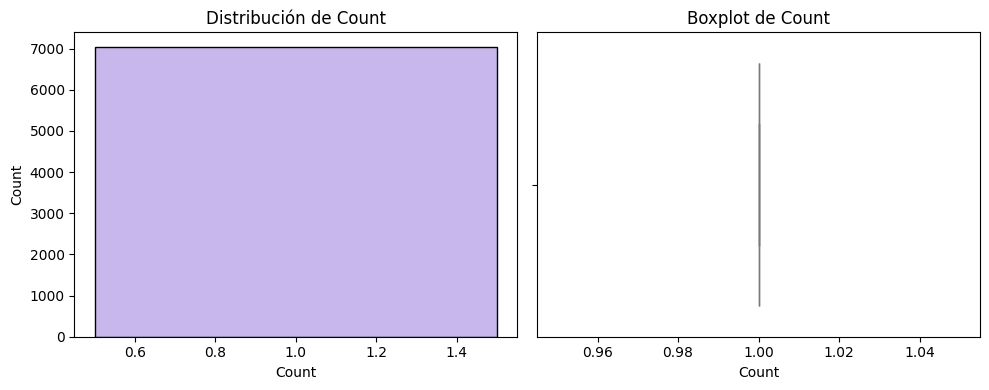

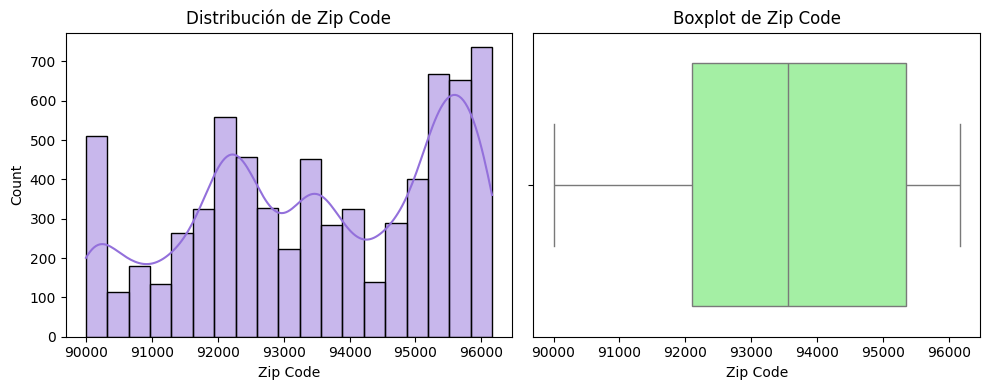

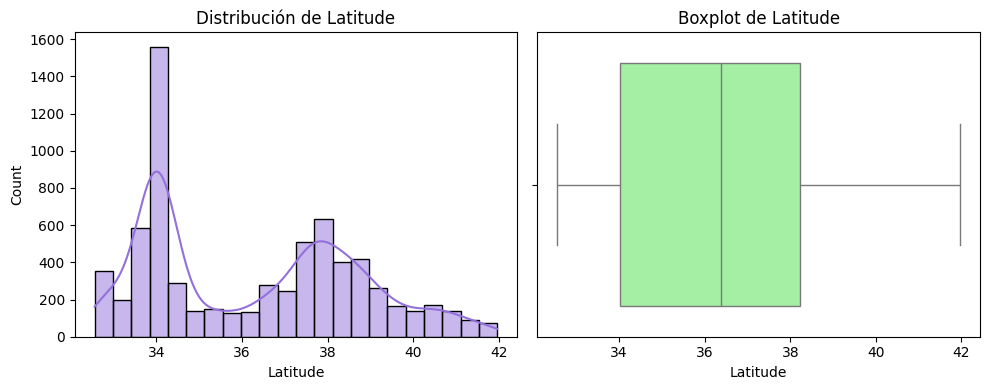

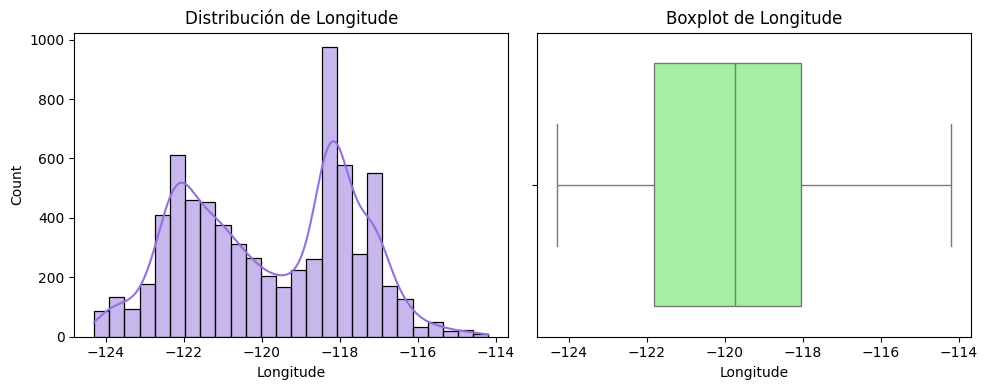

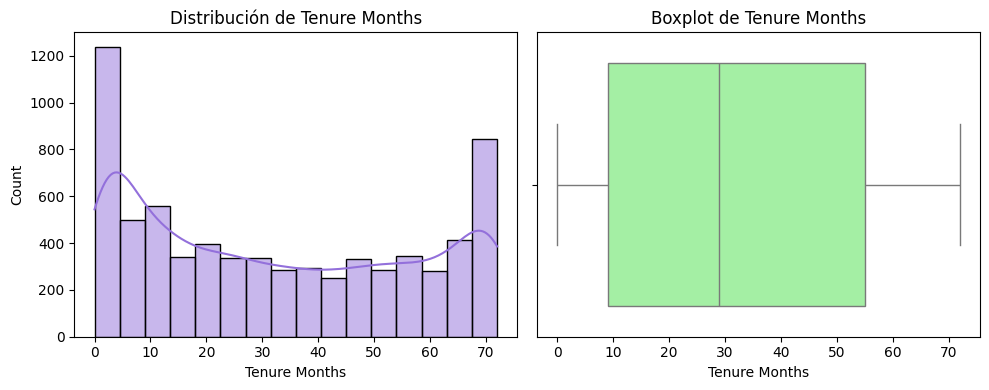

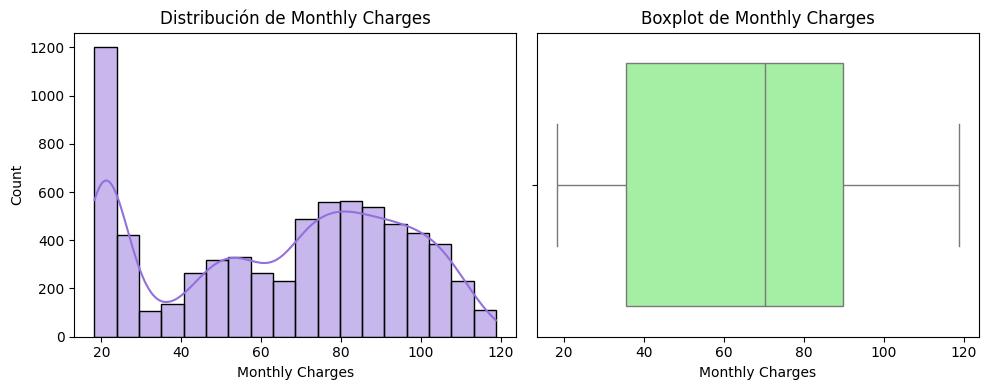

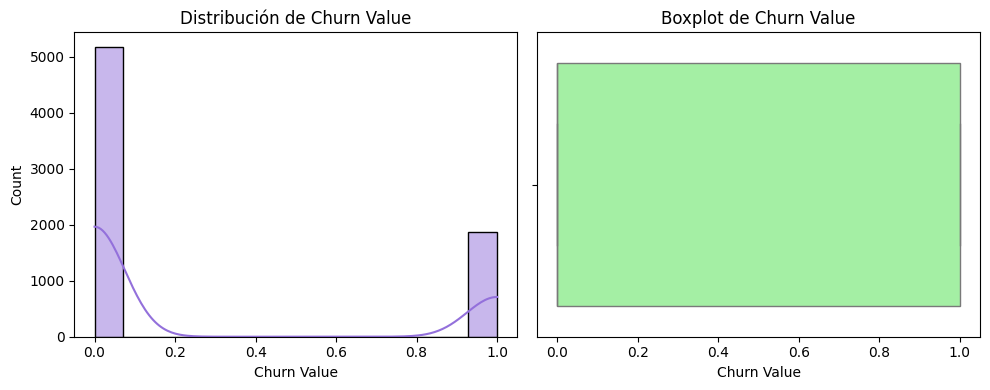

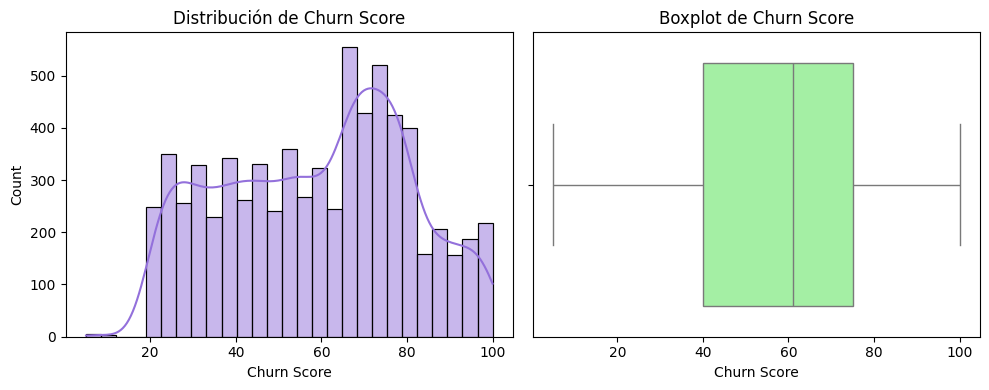

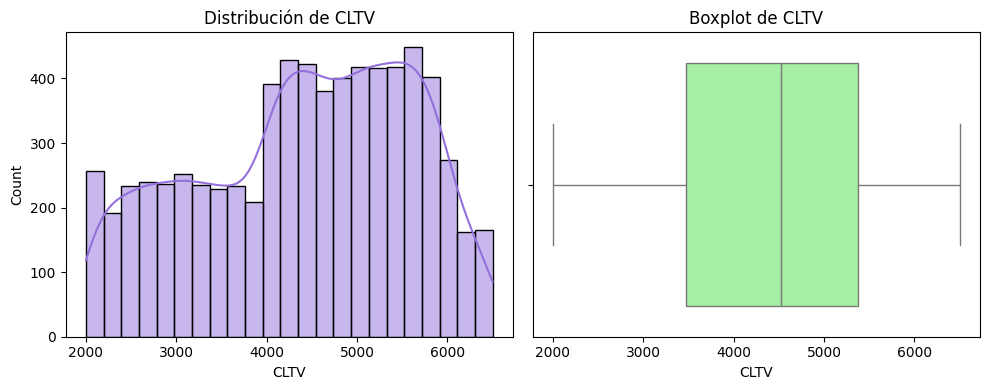

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

#Analisis de normalidad de las variables numericas
columnas_numericas = dataset.select_dtypes(include=[np.number]).columns
for col in columnas_numericas:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(dataset[col], kde=True, color='mediumpurple')
    plt.title(f"Distribución de {col}")
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=dataset[col], color="palegreen")
    plt.title(f"Boxplot de {col}")
    
    plt.tight_layout()
    plt.show()


In [9]:
from scipy import stats
import pandas as pd

# Utilizando shapiro milk
resultados = []
for var in columnas_numericas:
    datos = dataset[var].dropna()
    muestra = datos.sample(5000, random_state=42) if len(datos) > 5000 else datos
    stat, p = stats.shapiro(muestra)
    resultados.append({
        "Variable": var,
        "p_value": p,
        "Normal (p>0.05)": p > 0.05,
        "Skewness": datos.skew(),
        "Kurtosis": datos.kurtosis()
    })

res_df = pd.DataFrame(resultados).sort_values("p_value")
# RESUMEN
print(res_df[["Variable", "p_value", "Normal (p>0.05)"]])

normales = res_df[res_df["Normal (p>0.05)"]]["Variable"].tolist()
no_normales = res_df[~res_df["Normal (p>0.05)"]]["Variable"].tolist()

print(f"\nCumplen normalidad ({len(normales)}): {normales}")
print(f"No cumplen normalidad ({len(no_normales)}): {no_normales}")


          Variable       p_value  Normal (p>0.05)
6      Churn Value  1.022652e-77            False
4    Tenure Months  1.373476e-48            False
5  Monthly Charges  3.433502e-45            False
2         Latitude  6.701467e-45            False
1         Zip Code  3.986851e-42            False
3        Longitude  1.191794e-36            False
8             CLTV  3.173087e-34            False
7      Churn Score  8.770171e-32            False
0            Count  1.000000e+00             True

Cumplen normalidad (1): ['Count']
No cumplen normalidad (8): ['Churn Value', 'Tenure Months', 'Monthly Charges', 'Latitude', 'Zip Code', 'Longitude', 'CLTV', 'Churn Score']


/home/gradient/Proyectos/ap-2026-1-62/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


Despues de analizar las graficas podemos concluir , ninguna cumple con distribucion normal las mas parecidas son latitud y longitud y eso que son bimodales. Ademas de ello no existen outliers en las variables al analizar el boxplot

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

Resumen categórico:

Country:
               Frecuencia  Porcentaje(%)
Country                                 
United States        7043          100.0

State:
            Frecuencia  Porcentaje(%)
State                                
California        7043          100.0

Gender:
        Frecuencia  Porcentaje(%)
Gender                           
Male          3555           50.5
Female        3488           49.5

Senior Citizen:
                Frecuencia  Porcentaje(%)
Senior Citizen                           
No                    5901           83.8
Yes                   1142           16.2

Partner:
         Frecuencia  Porcentaje(%)
Partner                           
No             3641           51.7
Yes            3402           48.3

Dependents:
            Frecuencia  Porcentaje(%)
Dependents                           
No                5416           76.9
Yes               1627           23.1

Phone Service:
               Frecuencia  Porcentaje(%)
Phone Service          

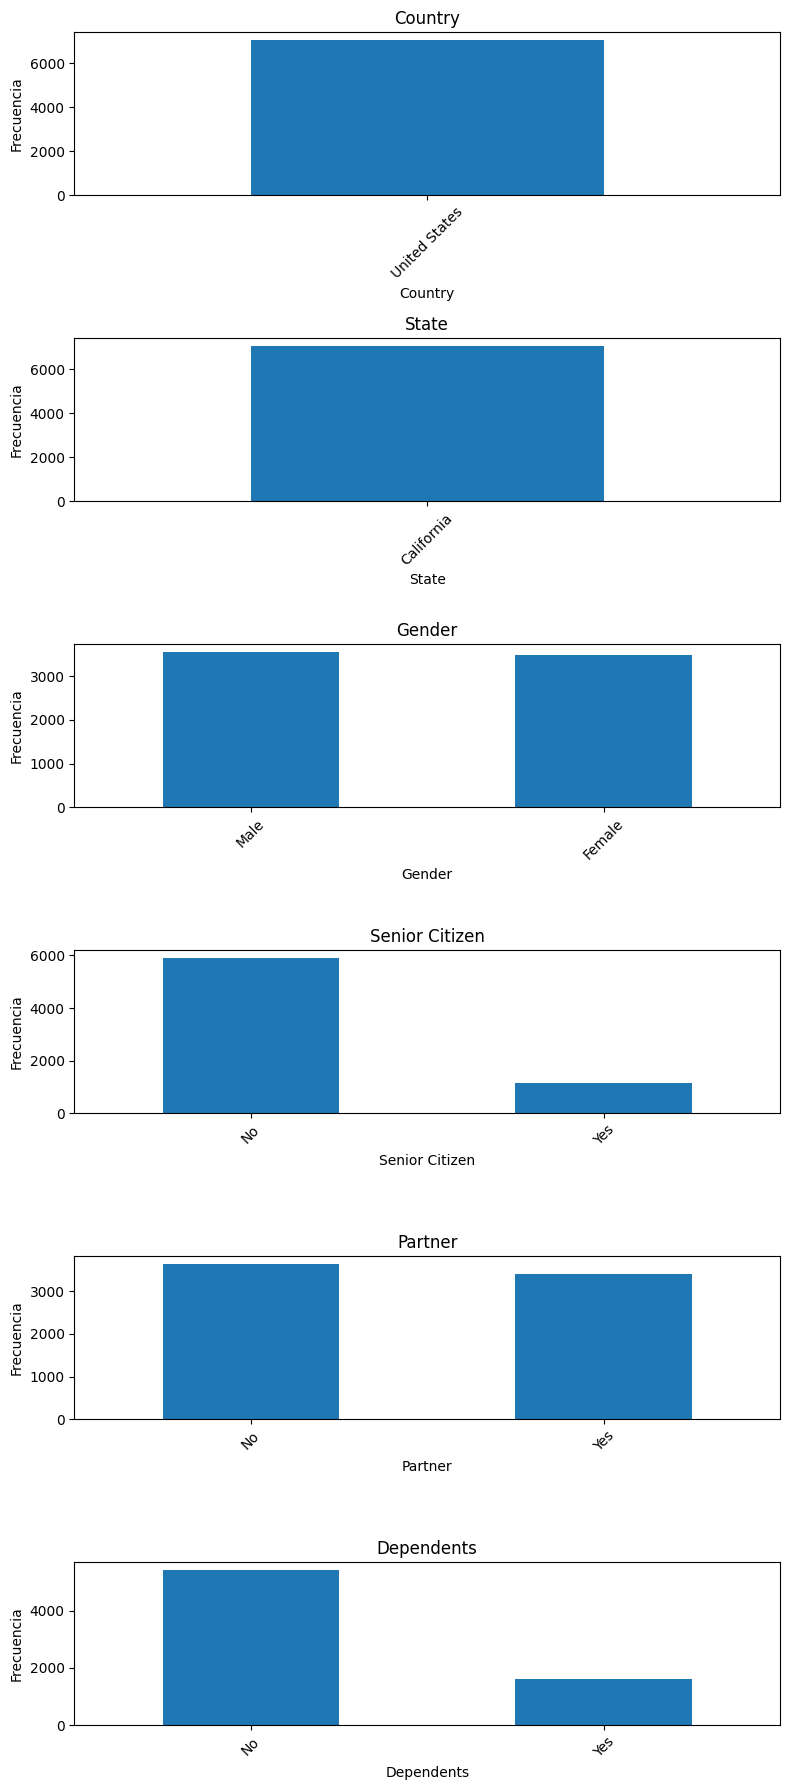

In [11]:
try:
    cat_cols = columnas_cat_analisis
except NameError:
    excluir = ['CustomerID', 'City', 'Lat Long', 'Churn Reason']
    cat_cols = [c for c in dataset.select_dtypes(include=['object']).columns if c not in excluir]

print("Resumen categórico:\n")
for c in cat_cols:
    vc = dataset[c].value_counts(dropna=False).head(6)
    pct = (dataset[c].value_counts(normalize=True, dropna=False).head(6) * 100).round(1)
    resumen = pd.DataFrame({'Frecuencia': vc, 'Porcentaje(%)': pct})
    print(f"{c}:\n{resumen}\n")

try:
    num_cols_plot = [c for c in cat_cols if dataset[c].nunique() <= 10][:6]
except Exception:
    num_cols_plot = []

if num_cols_plot:
    fig, axes = plt.subplots(len(num_cols_plot), 1, figsize=(8, 3 * len(num_cols_plot)))
    if len(num_cols_plot) == 1:
        axes = [axes]
    for ax, c in zip(axes, num_cols_plot):
        dataset[c].value_counts().plot(kind='bar', ax=ax, color='tab:blue')
        ax.set_title(c)
        ax.set_ylabel('Frecuencia')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

try:
    num_cols = columnas_numericas
except NameError:
    num_cols = dataset.select_dtypes(include=[np.number]).columns

outliers_info = []
for c in num_cols:
    s = dataset[c].dropna()
    if s.empty:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lower) | (s > upper)).sum()
    pct_out = n_out / len(dataset) * 100
    outliers_info.append((c, int(n_out), round(pct_out, 2)))



Tambien gracias a variables y celdas anteriores podemos concluir que existe alta cardinalidad en ciertas variables como lo son city, ,latitud customerID

## Paso 6: Análisis bivariado.

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la **Churn Value**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


VARIABLES CUANTITATIVAS vs Churn Value


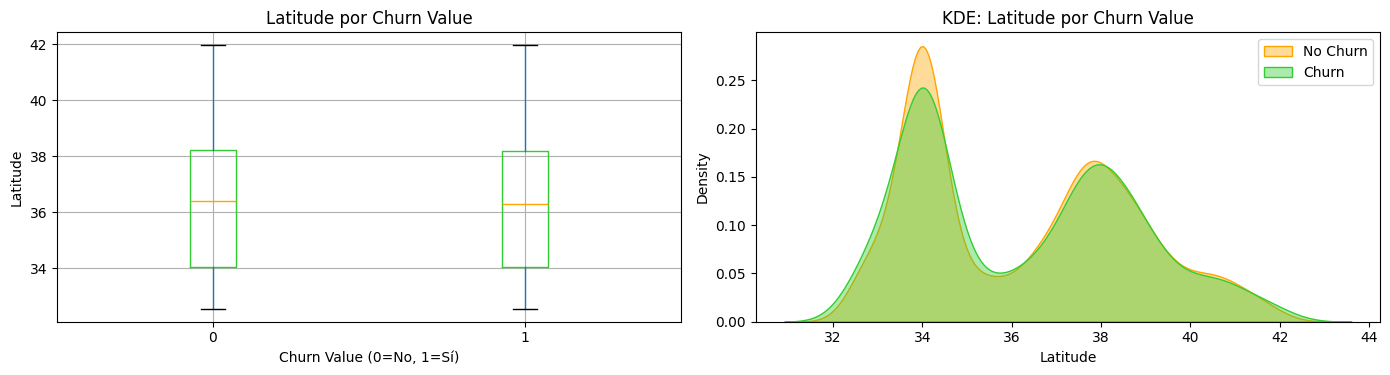

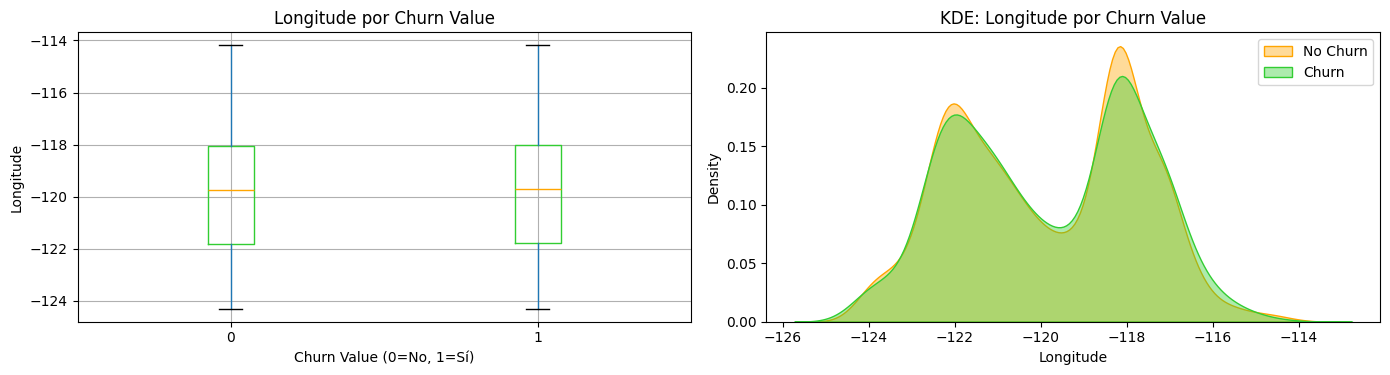

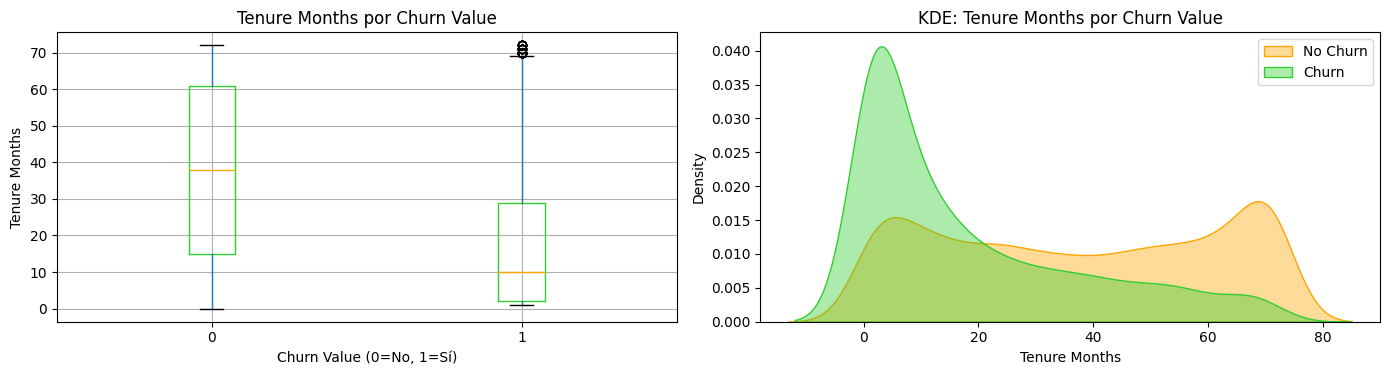

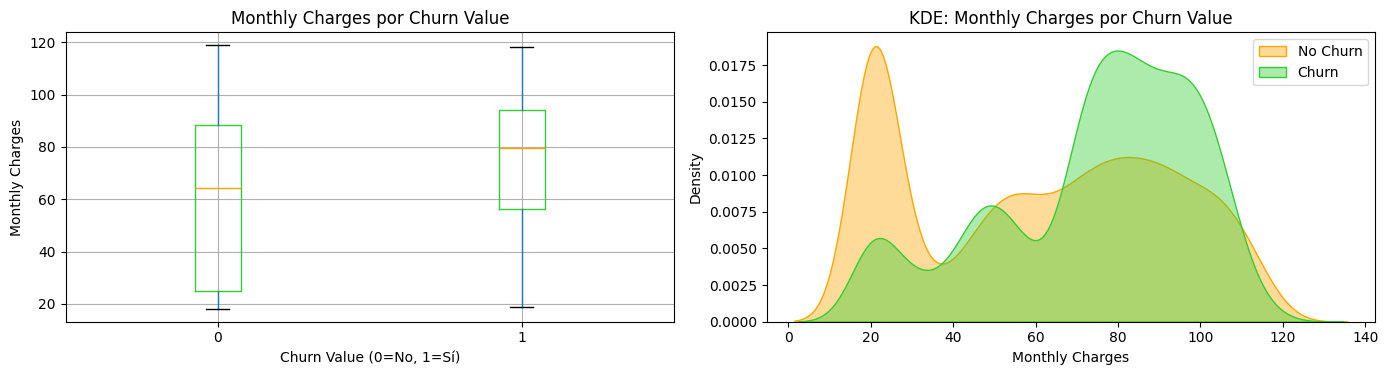

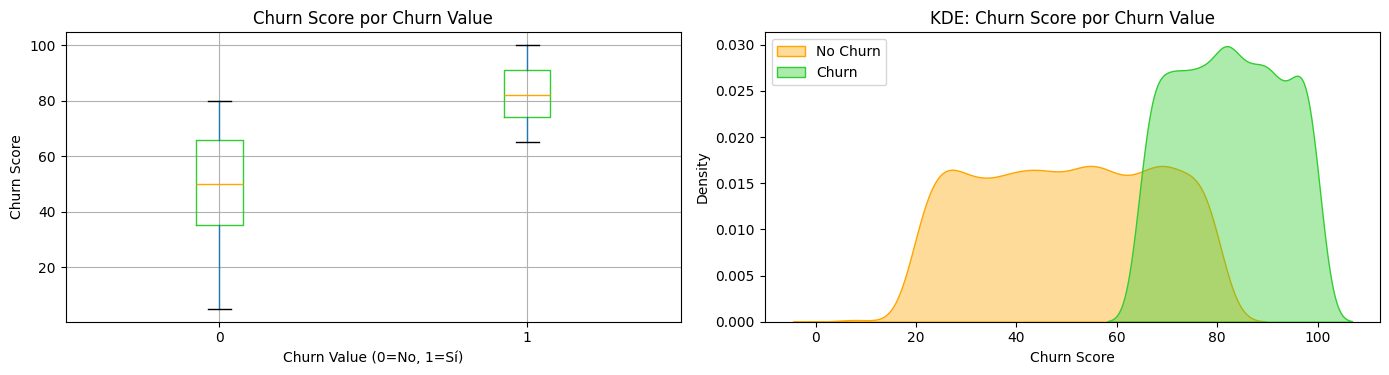

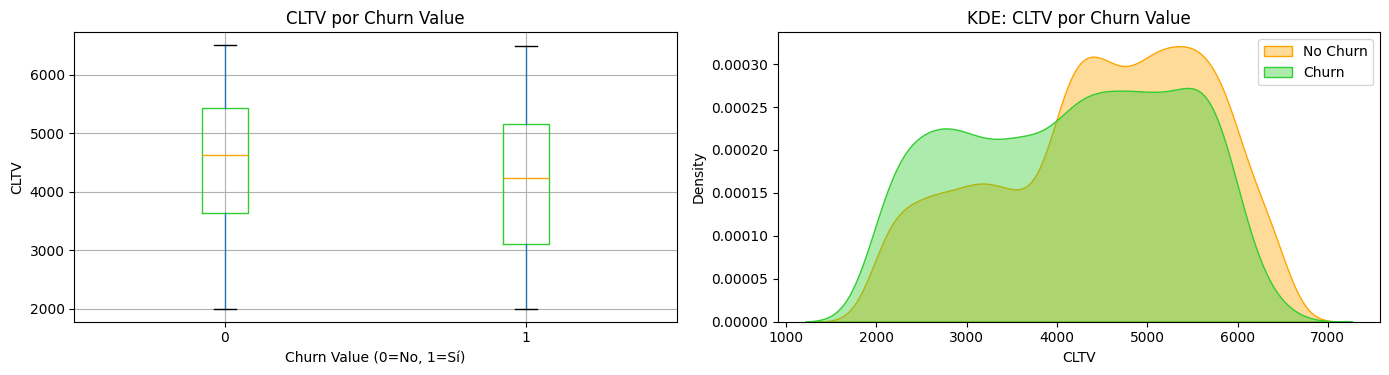


Correlación de variables cuantitativas con Churn Value:
Churn Score        0.664897
Tenure Months     -0.352229
Monthly Charges    0.193356
CLTV              -0.127463
Longitude          0.004594
Latitude          -0.003384
Zip Code           0.003346
Count                   NaN
VARIABLES CUALITATIVAS vs Churn Value


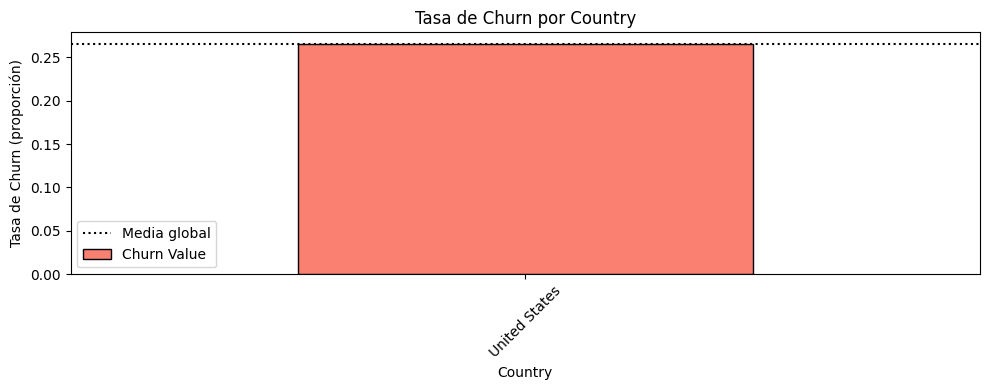

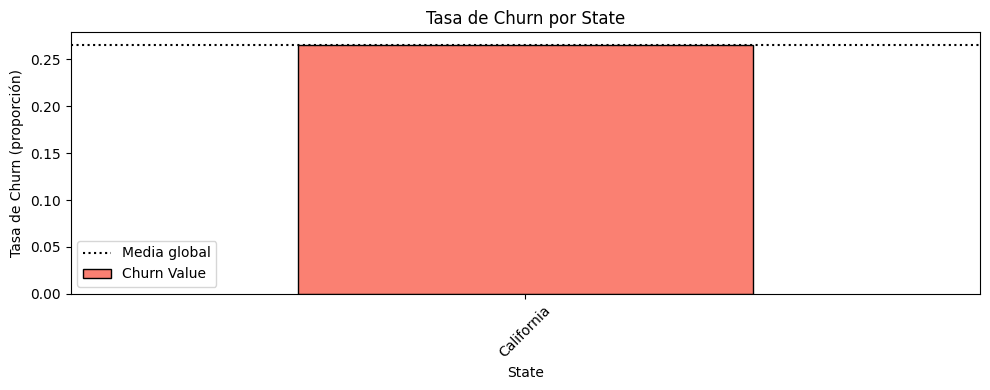

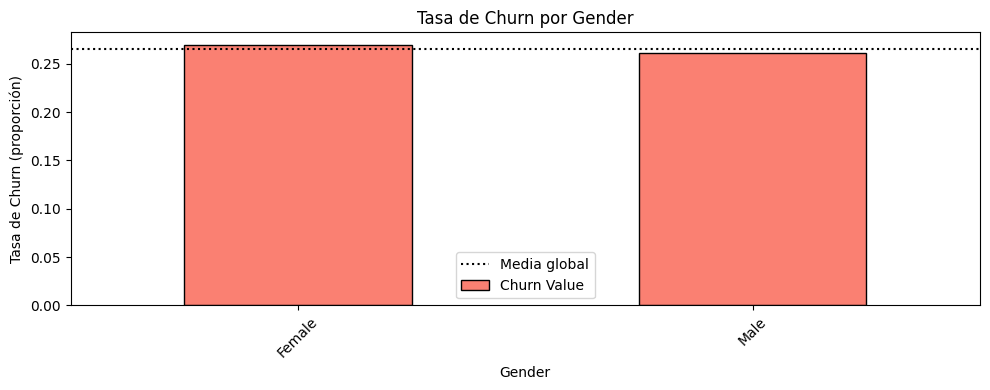

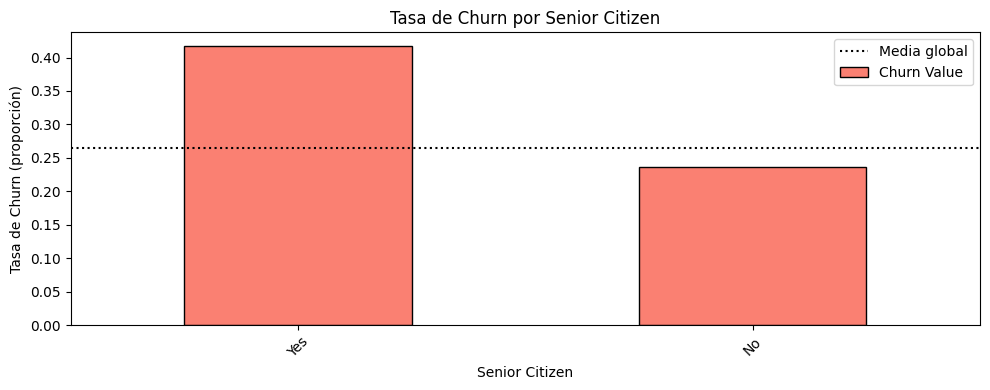

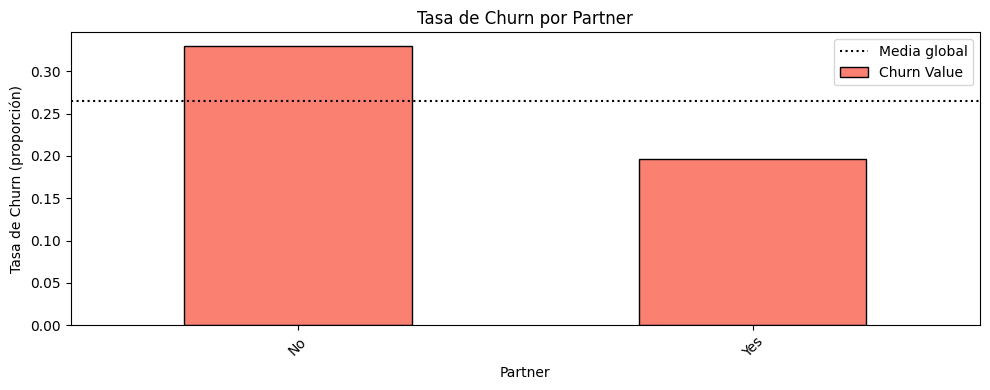

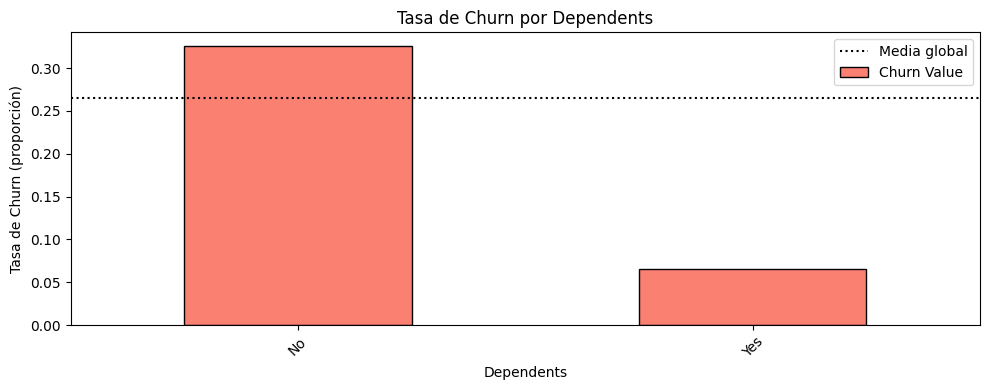

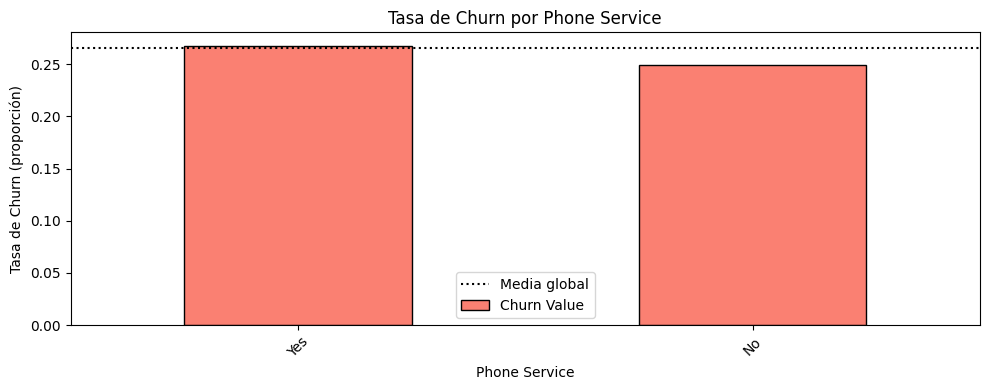

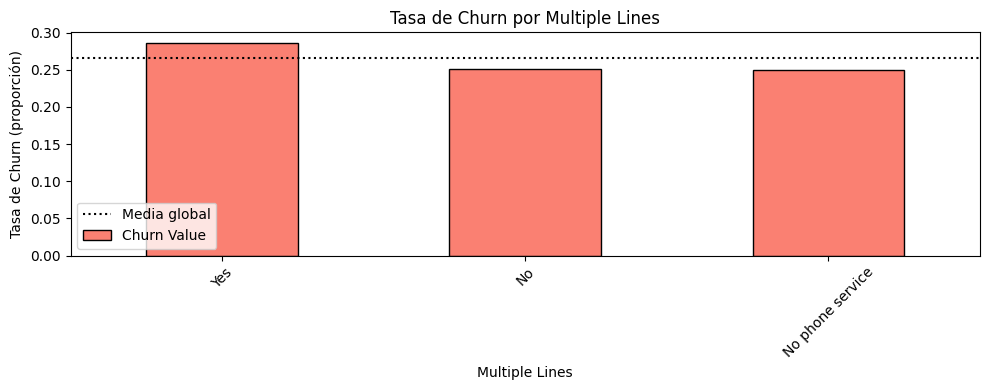

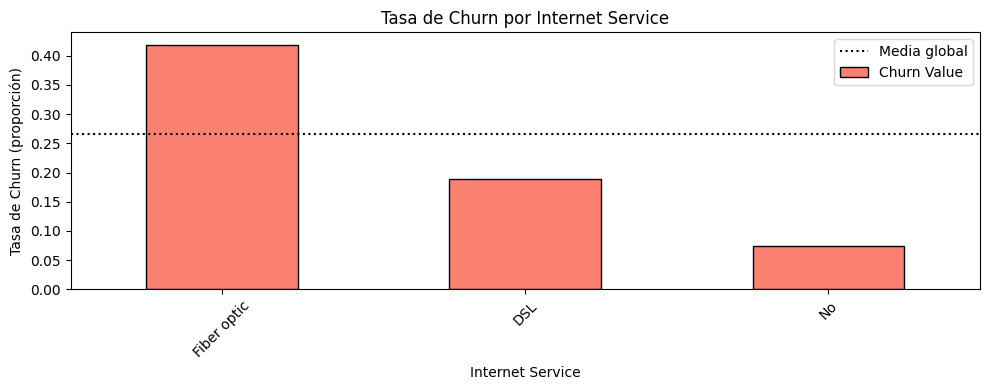

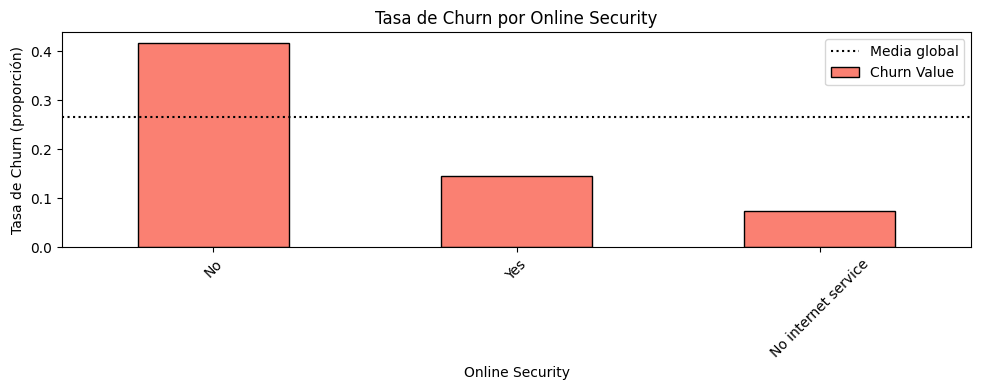

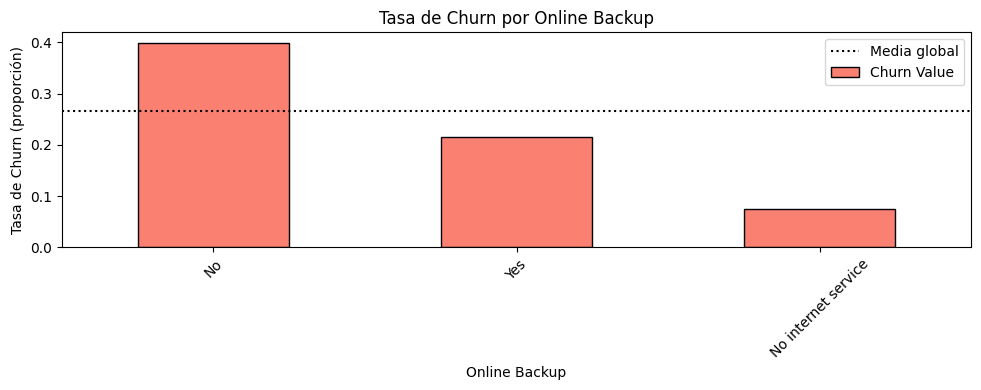

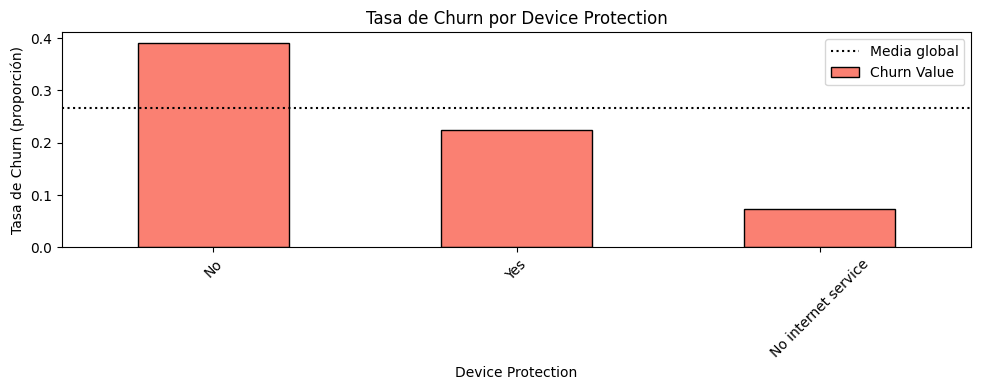

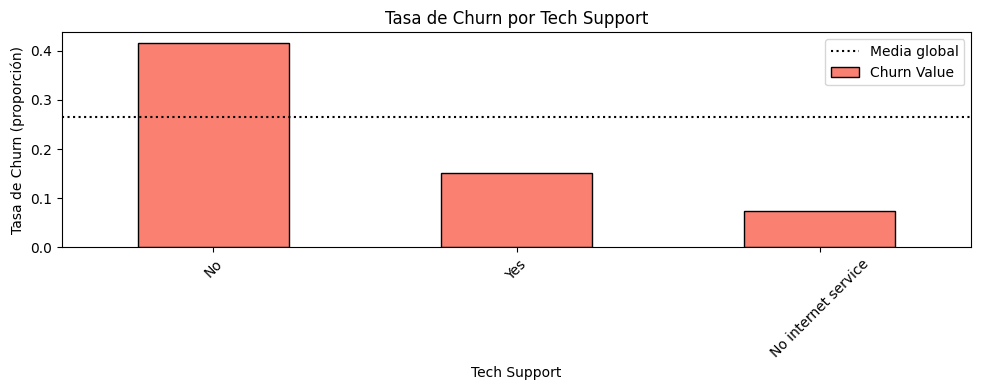

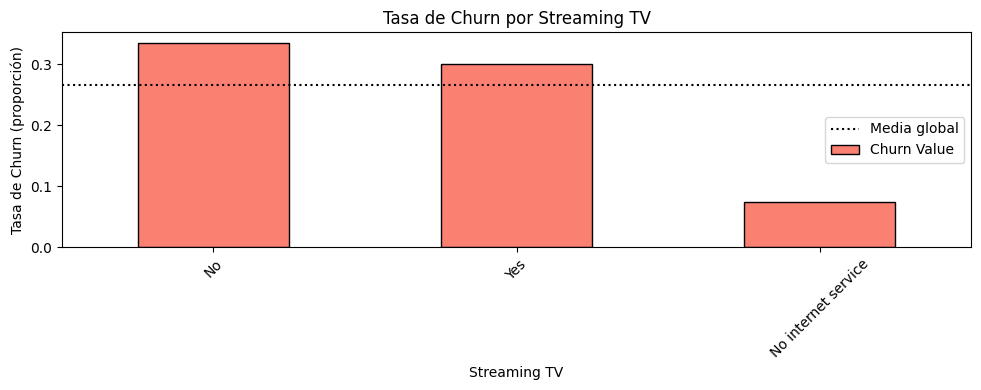

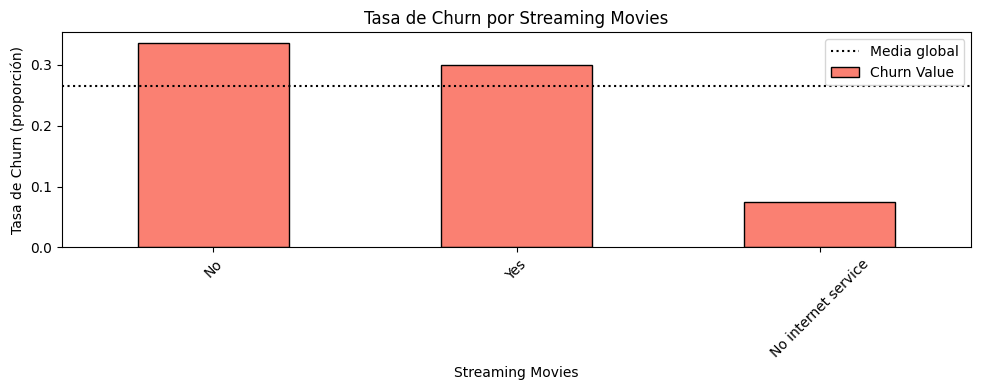

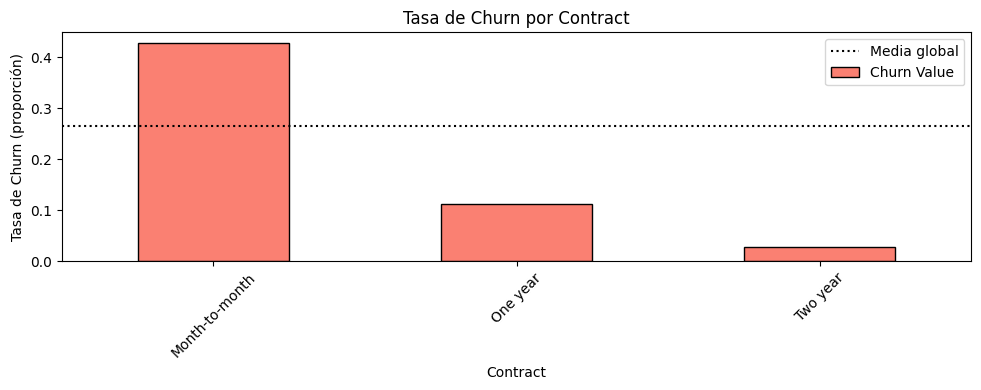

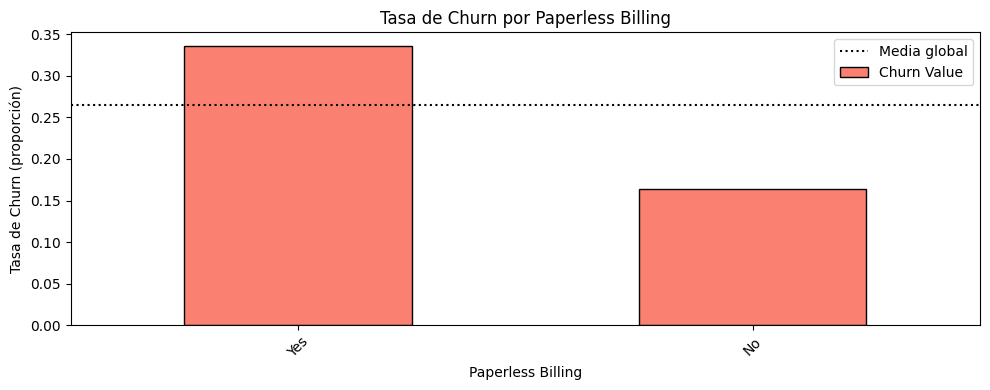

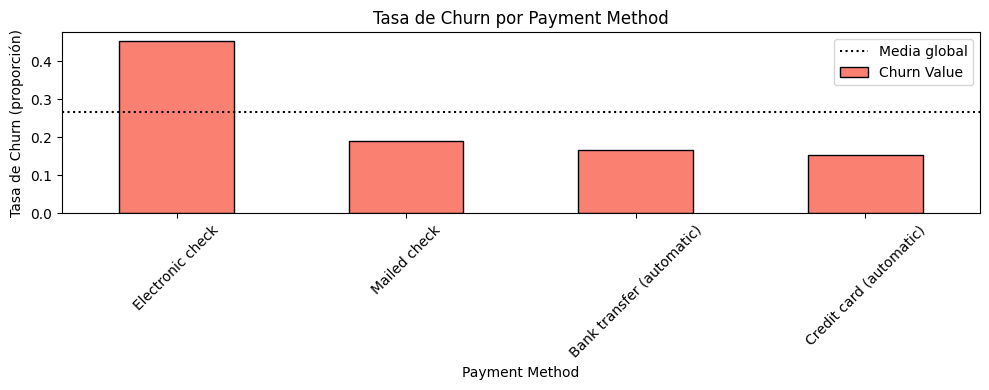

Posibles predictoras

Cuantitativas a con Churn Value):
Churn Score        0.664897
Tenure Months     -0.352229
Monthly Charges    0.193356
CLTV              -0.127463
Longitude          0.004594
Latitude          -0.003384
Zip Code           0.003346
Count                   NaN

Cualitativas (por variación en tasa de churn entre categorías):
  Country: variación=0.000  (max=0.265, min=0.265)
  State: variación=0.000  (max=0.265, min=0.265)
  Gender: variación=0.008  (max=0.269, min=0.262)
  Senior Citizen: variación=0.181  (max=0.417, min=0.236)
  Partner: variación=0.133  (max=0.330, min=0.197)
  Dependents: variación=0.260  (max=0.326, min=0.065)
  Phone Service: variación=0.018  (max=0.267, min=0.249)
  Multiple Lines: variación=0.037  (max=0.286, min=0.249)
  Internet Service: variación=0.345  (max=0.419, min=0.074)
  Online Security: variación=0.344  (max=0.418, min=0.074)
  Online Backup: variación=0.325  (max=0.399, min=0.074)
  Device Protection: variación=0.317  (max=0.391, m

In [19]:
# Análisis Churn Value

objective = 'Churn Value'

# Cuantitativas vs Churn Value
quant_cols = [c for c in columnas_numericas if c != objective and c not in ['Count', 'Zip Code']]

print("VARIABLES CUANTITATIVAS vs Churn Value")

for col in quant_cols:
    fig, axes_plot = plt.subplots(1, 2, figsize=(14, 4))
    
    ax1 = axes_plot[0]
    dataset.boxplot(column=col, by=objective, ax=ax1,
                    boxprops=dict(color='limegreen'),
                    medianprops=dict(color='orange'))
    ax1.set_title(f"{col} por Churn Value")
    ax1.set_xlabel("Churn Value (0=No, 1=Sí)")
    ax1.set_ylabel(col)

    ax2 = axes_plot[1]
    
    for val, label, color in [(0, 'No Churn', 'orange'), (1, 'Churn', 'limegreen')]:
        subset = dataset[dataset[objective] == val][col].dropna()
        sns.kdeplot(subset, ax=ax2, label=label, color=color, fill=True, alpha=0.4)
    ax2.set_title(f"KDE: {col} por Churn Value")
    ax2.set_xlabel(col)
    ax2.legend()

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

print("\nCorrelación de variables cuantitativas con Churn Value:")
corr_objective = dataset[columnas_numericas].corr()[objective].drop(objective).sort_values(key=abs, ascending=False)
print(corr_objective.to_string())

# Cualitativas vs Churn Value
qual_cols = [c for c in cat_cols if c != 'Churn Label' and dataset[c].nunique() <= 15]

print("VARIABLES CUALITATIVAS vs Churn Value")

for col in qual_cols:
    fig2, ax_qual = plt.subplots(figsize=(10, 4))
    churn_rate = dataset.groupby(col)[objective].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax_qual, color='salmon', edgecolor='black')
    ax_qual.set_title(f"Tasa de Churn por {col}")
    ax_qual.set_ylabel("Tasa de Churn (proporción)")
    ax_qual.set_xlabel(col)
    ax_qual.axhline(dataset[objective].mean(), color='black', linestyle='dotted', label='Media global')
    ax_qual.legend()
    ax_qual.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

print("Posibles predictoras")

print("\nCuantitativas a con Churn Value):")
print(corr_objective.to_string())

print("\nCualitativas (por variación en tasa de churn entre categorías):")
for col in qual_cols:
    tasas = dataset.groupby(col)[objective].mean()
    variacion = tasas.max() - tasas.min()
    print(f"  {col}: variación={variacion:.3f}  (max={tasas.max():.3f}, min={tasas.min():.3f})")
